In [5]:
%%capture
!pip install scikit-learn

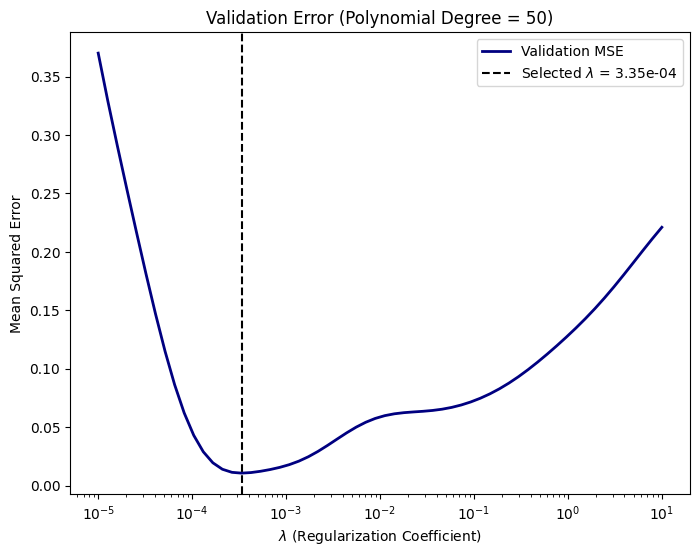

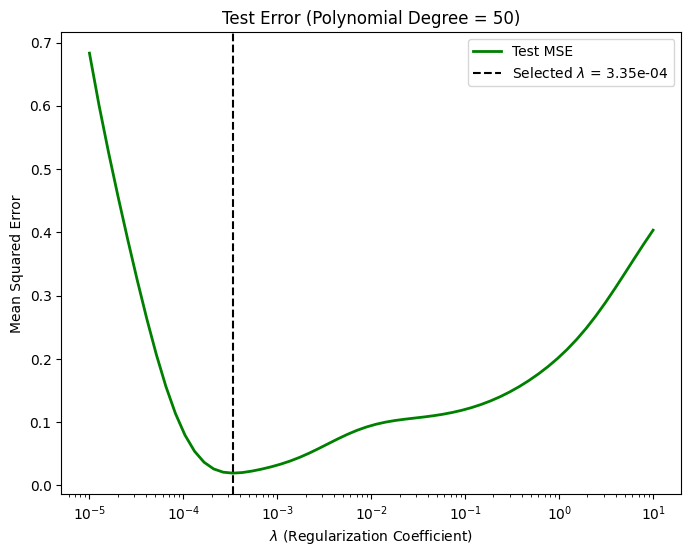

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Define the true function
def true_function(x):
    return np.sin(2 * np.pi * x)

# Generate data points
np.random.seed(0)
n = 25
x = np.random.rand(n)
y = true_function(x) + np.random.normal(0, 0.1, n)

# Split the data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3, random_state=42)

# Generate an independent large test set
n_test = 1000
x_test = np.linspace(0, 1, n_test)
y_test = true_function(x_test)

# Define polynomial degree
degree = 50

# Define the range of lambda values
lambdas = np.logspace(-5, 1, 60)

# Initialize lists to store MSE values
train_mse = []
val_mse = []
test_mse = []

# Loop over lambda values
for _lambda in lambdas:
    # Create a pipeline with polynomial features and Ridge regression
    model = make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        Ridge(alpha=_lambda)
    )

    # Fit the model on the training data
    model.fit(x_train[:, np.newaxis], y_train)
    
    # Predict and calculate MSE for training set
    y_train_pred = model.predict(x_train[:, np.newaxis])
    train_mse.append(mean_squared_error(y_train, y_train_pred))
    
    # Predict and calculate MSE for validation set
    y_val_pred = model.predict(x_val[:, np.newaxis])
    val_mse.append(mean_squared_error(y_val, y_val_pred))
    
    # Predict and calculate MSE for test set
    y_test_pred = model.predict(x_test[:, np.newaxis])
    test_mse.append(mean_squared_error(y_test, y_test_pred))

# Identify the lambda with the minimum validation MSE
selected_lambda = lambdas[np.argmin(val_mse)]

# Create a figure for training and validation error
plt.figure(figsize=(8, 6))
# plt.title(f"Training and Validation Error (Polynomial Degree = {degree})")
plt.title(f"Validation Error (Polynomial Degree = {degree})")
plt.xlabel(r"$\lambda$ (Regularization Coefficient)")
plt.ylabel("Mean Squared Error")
plt.xscale("log")

# Plot training and validation MSE
# plt.plot(lambdas, train_mse, label="Training MSE", color="darkorange", lw=2)
plt.plot(lambdas, val_mse, label="Validation MSE", color="navy", lw=2)

# Mark the Selected lambda
plt.axvline(selected_lambda, linestyle="--", color="k",
            label=f"Selected $\\lambda$ = {selected_lambda:.2e}")

plt.legend(loc="best")
plt.show()

# Create a separate figure for test error
plt.figure(figsize=(8, 6))
plt.title(f"Test Error (Polynomial Degree = {degree})")
plt.xlabel(r"$\lambda$ (Regularization Coefficient)")
plt.ylabel("Mean Squared Error")
plt.xscale("log")

# Plot test MSE
plt.plot(lambdas, test_mse, label="Test MSE", color="green", lw=2)

# Mark the selected lambda
plt.axvline(selected_lambda, linestyle="--", color="k",
            label=f"Selected $\\lambda$ = {selected_lambda:.2e}")

plt.legend(loc="best")
plt.show()